# M2 Agentic AI - 图表生成

欢迎来到 **Agentic AI** 课程！在本次**无评分实验**以及后续实验中，你将亲手运行示例代码，体验视频课程中的概念与设计模式如何落地到实际工作流。

你可以把这些实验当作一个**沙盒**：安全的练习空间，帮助你加深对课程概念的理解、建立信心，并为后续的评分作业做好准备。每个实验都建议你运行代码单元，直观看到智能体工作流的执行过程，从而更好地理解其机制。

在部分步骤中，我们也鼓励你**尝试修改代码**——例如调整提示词、测试不同的 LLM，或给工作流增加额外查询。请大胆实验，观察这些改动如何影响工作流行为。

更重要的是，无评分实验让你能以自己的节奏学习，并获得 **Agentic AI** 核心理念的动手实践体验。如果你有任何问题，欢迎在
<a href="https://community.deeplearning.ai/c/course-q-a/agentic-ai/567" target="_blank">社区</a>


## 1. 引言
### 1.1. 实验概览

在本次无评分实验中，你将把视频中介绍的**反思（Reflection）模式**应用到一个用于生成数据可视化的智能体工作流中。一个多模态 LLM 会审阅第一版图表，识别潜在改进点（如图表类型、标签或配色），并重写绘图代码以生成更有效的可视化。

在视频中，Andrew 展示了一个用于分析咖啡销售的工作流；你将在此用代码实现它。该工作流将执行以下步骤：

1. **生成初始版本（V1）：**
使用大语言模型（LLM）生成第一版绘图代码。

2. **执行代码并生成图表：** 
运行生成的代码并展示图表。

3. **对输出进行反思：**
使用 LLM 评估代码与图表，发现可改进之处（如清晰度、准确性、设计）。

4. **生成并执行改进版本（V2）：**
根据反思建议生成更优的绘图代码，并渲染增强后的图表。

<img src='M2-UGL-2.png'>

### 🎯 1.2. 学习目标

在本实验结束时，你将完成反思模式的代码实现，并用它改进一个数据可视化。

## 2. 环境设置：初始化环境与客户端

在本步骤中，你将导入支撑该工作流的关键库：  

- **`re`**：Python 的正则表达式模块，用于从 LLM 输出中提取代码片段或结构化文本。  
- **`json`**：用于读写 JSON，方便处理 LLM 返回的结构化响应。  
- **`utils`**：本实验提供的自定义辅助模块，包含用于处理数据集、生成图表以及以简洁可读的格式展示结果的工具函数。  


In [1]:
import os
# 使用 硅基流动的 API
SILICONFLOW_API_BASE_URL = "https://api.siliconflow.cn/v1"
SILICONFLOW_API_KEY = os.getenv("SILICONFLOW_API_KEY")

# 设置 环境变量使用 硅基流动 API
os.environ['OPENAI_BASE_URL'] = SILICONFLOW_API_BASE_URL
os.environ['OPENAI_API_KEY'] = SILICONFLOW_API_KEY
os.environ['ANTHROPIC_BASE_URL'] = SILICONFLOW_API_BASE_URL
os.environ['ANTHROPIC_API_KEY'] = SILICONFLOW_API_KEY

In [2]:
# 标准库导入
import re
import json

# 本地辅助模块
import utils

### 2.1. 加载数据集

先快速查看一下咖啡销售数据文件，了解其中包含哪些信息。

In [3]:
# 使用 utils.py 提供的函数将数据加载到 DataFrame
df = utils.load_and_prepare_data('coffee_sales.csv')

# 抽取一个随机样本进行展示
utils.print_html(df.sample(n=5), title="咖啡销售数据的随机样本")

date,time,cash_type,card,price,coffee_name,quarter,month,year
2025-03-18,15:55,card,ANON-0000-0000-1163,3.576,Cocoa,1,3,2025
2025-02-05,15:27,card,ANON-0000-0000-1165,3.576,Hot Chocolate,1,2,2025
2025-02-28,15:28,card,ANON-0000-0000-1190,2.596,Americano,1,2,2025
2024-05-20,14:41,card,ANON-0000-0000-0195,2.792,Cortado,2,5,2024
2025-02-05,09:47,card,ANON-0000-0000-1171,2.106,Espresso,1,2,2025


你将基于该数据集构建一个生成数据可视化的智能体工作流，帮助回答有关自动售卖机咖啡销售情况的问题。

## 3. 构建流水线

### 3.1 步骤 1 — 生成用于绘图的代码（V1）

在此步骤中，你将提示 LLM 编写 Python 代码，以响应针对咖啡数据集的用户查询并生成图表。该数据集包含诸如 `date`、`coffee_type`、`quantity`、`revenue` 等字段，你会将这些模式信息传给 LLM，让它了解可用数据。  

你要询问模型的问题与课程视频中一致：  
**“使用 coffee_sales.csv 中的数据，创建一张对比 2024 与 2025 年第一季度咖啡销售的图表。”**

LLM 的输出将是使用 **matplotlib** 库的 Python 代码。代码不会直接显示图表，而是会被写在 `<execute_python>` 标签之间，以便在后续步骤中提取并执行。关于这些标签，你会在模块 3 中学到更多。  


In [4]:
def generate_chart_code(instruction: str, model: str, out_path_v1: str) -> str:
    """生成使用 matplotlib 绘图的 Python 代码，并用标签包裹返回。"""

    prompt = f"""
    你是一位数据可视化专家。

    请*严格*按以下格式返回你的答案：

    <execute_python>
    # 在此填写有效的 Python 代码
    </execute_python>

    不要添加任何解释，仅包含上述标签与代码。

    代码需基于名为 'df' 的 DataFrame 生成可视化，其列包括：
    - date (M/D/YY)
    - time (HH:MM)
    - cash_type (card 或 cash)
    - card (string)
    - price (number)
    - coffee_name (string)
    - quarter (1-4)
    - month (1-12)
    - year (YYYY)

    用户指令：{instruction}

    代码要求：
    1. 假设 DataFrame 已加载为 'df'。
    2. 使用 matplotlib 进行绘图。
    3. 添加清晰的标题、坐标轴标签，并在需要时添加图例。
    4. 将图像以 '{out_path_v1}' 保存，dpi=300。
    5. 不要调用 plt.show()。
    6. 使用 plt.close() 关闭所有图。
    7. 补充所有必要的 import 语句。

    仅返回包含在 <execute_python> 标签中的代码。
    """

    response = utils.get_response(model, prompt)
    return response

现在试用一下该函数，并分析它的响应！

In [7]:
model_1 = "Qwen/Qwen2.5-Coder-7B-Instruct"  # 使用基础文本模型

# 生成初始代码
code_v1 = generate_chart_code(
    instruction="使用 coffee_sales.csv 中的数据，创建一张对比 2024 与 2025 年第一季度咖啡销售的图表。", 
    #model="gpt-4o-mini", 
    model=model_1,
    out_path_v1="chart_v1.png"
)

utils.print_html(code_v1, title="LLM 输出的首版代码")

很好！你已经生成了用于创建图表的 Python 代码！

请注意，代码被包裹在 `<execute_python>` 标签之间。借助这些标签，你可以在工作流的下一步中方便地自动提取并运行代码。  

暂时不必担心其实现细节 —— 你会在**模块 3**中进一步了解这些标签的工作方式。  


### 3.2. 步骤 2 — 执行代码并创建图表

在此步骤中，你将使用正则表达式提取上一环节由 LLM 生成的 Python 代码（包裹在 `<execute_python>` 标签之间的部分）。提取后运行该代码以生成**首版图表**。  

其工作原理如下：

1. **提取代码：**  
   使用正则表达式匹配 `<execute_python>` 标签内的代码。

2. **执行代码：**
   在预定义的全局上下文中运行提取到的代码，其中 DataFrame `df` 已可用。你的代码可以直接使用 df，而无需重新加载数据集。

3. **生成图表：**
   若代码执行成功，会生成图表并保存为 `chart_v1.png`。

4. **在笔记本中查看图表：**
   使用 `utils.print_html` 内联显示已保存的图表，方便你审阅结果。

完成本步骤后，你将得到首版可视化（V1）——这是反思工作流中的一个重要里程碑！


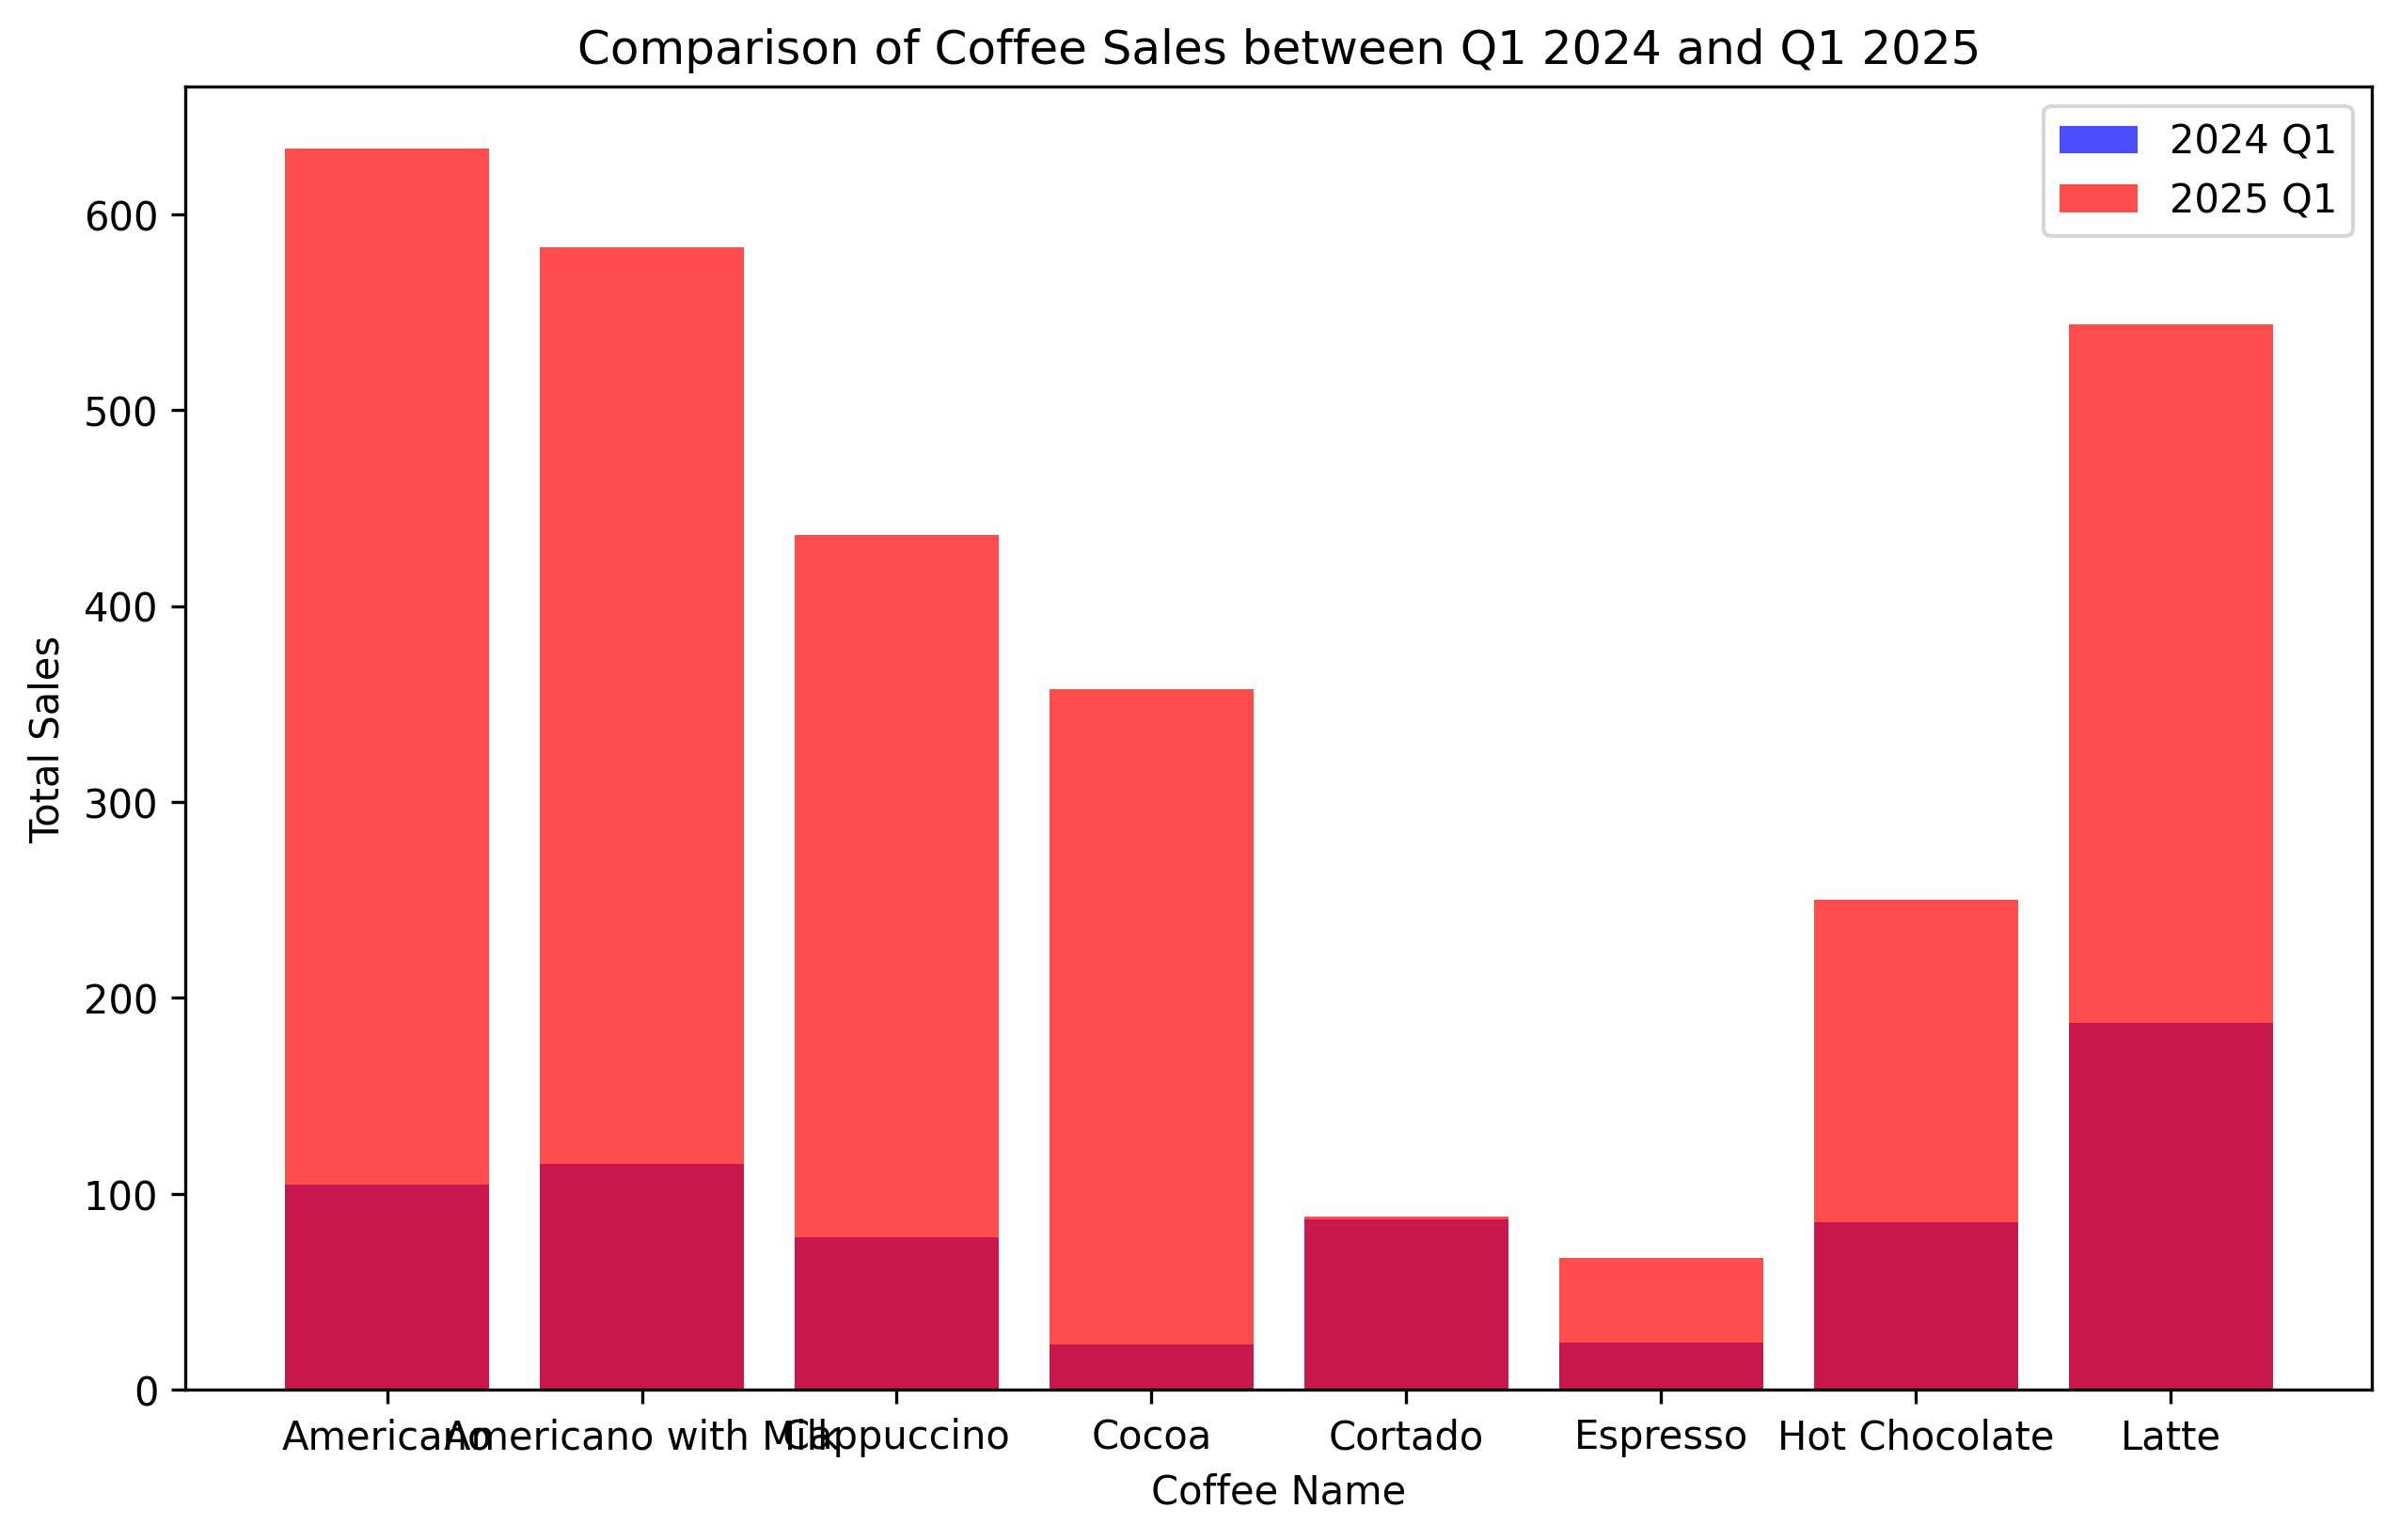

In [8]:
# 提取 <execute_python> 标签中的代码
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1)
if match:
    initial_code = match.group(1).strip()
    utils.print_html(initial_code, title="提取出的待执行代码")
    exec_globals = {"df": df}
    exec(initial_code, exec_globals)

# 若代码运行成功，将生成文件 chart_v1.png
utils.print_html(
    content="chart_v1.png",
    title="生成的图表（V1）",
    is_image=True
)

### 3.3. 步骤 3 — 对输出进行反思

此处的目标是模拟人类审阅图表首版草稿的过程——关注其优点、缺点以及可改进的方面。

具体包括：

**1. 将图表提供给 LLM：**
将生成的图表（chart_v1.png）传给 LLM，使其能够“看到”该可视化。

**2. 对图表进行视觉分析：**
LLM 会审阅清晰度、标注、准确性以及整体可读性等要素。

**3. 生成反馈：**
LLM 会提出改进建议——例如修正坐标轴标签、调整图表类型、改进配色或补充缺失的图例。

通过这一过程，你建立了一个智能反馈循环：图表不是一次性产出，而是会被主动评审，从而为更好的第二版本（V2）打下基础。

In [9]:
def reflect_on_image_and_regenerate(
    chart_path: str,
    instruction: str,
    model_name: str,
    out_path_v2: str,
    code_v1: str,  
) -> tuple[str, str]:
    """
    根据给定指令评审图表图像与原始代码，
    然后返回改进后的 matplotlib 代码。
    返回值：(feedback, refined_code_with_tags)。
    支持 OpenAI 与 Anthropic（Claude）。
    """
    media_type, b64 = utils.encode_image_b64(chart_path)   # 编码图像为 base64
    
    prompt = f"""
    你是一位数据可视化专家。
    你的任务：依据给定指令评审附件中的图表与原始代码，
    并返回改进后的 matplotlib 代码。

    原始代码（用于提供上下文）：
    {code_v1}

    输出格式（严格遵守！）：
    1) 第一行：仅包含 "feedback" 字段的有效 JSON 对象。
    示例：{{"feedback": "图例不清晰，且坐标轴标签存在重叠。"}}

    2) 换行后，仅输出用如下标签包裹的改进版 Python 代码：
    <execute_python>
    ...
    </execute_python>

    3) 在代码中导入所有必要的库。不要依赖原始代码中的 import。

    强约束：
    - 除上述两部分外，不要包含 Markdown、反引号或任何额外说明文字。
    - 仅使用 pandas/matplotlib（不使用 seaborn）。
    - 假设 df 已存在；不要从文件读取。
    - 保存到 '{out_path_v2}'，dpi=300。
    - 结尾始终调用 plt.close()（不要使用 plt.show()）。
    - 包含所有必要的 import 语句。

    架构（df 中可用的列）：
    - date (M/D/YY)
    - time (HH:MM)
    - cash_type (card 或 cash)
    - card (string)
    - price (number)
    - coffee_name (string)
    - quarter (1-4)
    - month (1-12)
    - year (YYYY)

    指令：
    {instruction}
    """

    # 若模型名称包含 "Claude" 或 "Anthropic"，使用安全辅助方法
    lower = model_name.lower()
    if "claude" in lower or "anthropic" in lower:
        # ✅ 使用安全辅助方法：合并所有文本块并加入系统提示
        content = utils.image_anthropic_call(model_name, prompt, media_type, b64)
    else:
        content = utils.image_openai_call(model_name, prompt, media_type, b64)

    # --- 仅解析第一行 JSON（feedback） ---
    lines = content.strip().splitlines()
    json_line = lines[0].strip() if lines else ""

    try:
        obj = json.loads(json_line)
    except Exception as e:
        # 回退：尝试在完整内容中捕获第一个 {...}
        m_json = re.search(r"\{.*?\}", content, flags=re.DOTALL)
        if m_json:
            try:
                obj = json.loads(m_json.group(0))
            except Exception as e2:
                obj = {"feedback": f"Failed to parse JSON: {e2}", "refined_code": ""}
        else:
            obj = {"feedback": f"Failed to find JSON: {e}", "refined_code": ""}

    # --- 从 <execute_python>...</execute_python> 中提取改进代码 ---
    m_code = re.search(r"<execute_python>([\s\S]*?)</execute_python>", content)
    refined_code_body = m_code.group(1).strip() if m_code else ""
    refined_code = utils.ensure_execute_python_tags(refined_code_body)

    feedback = str(obj.get("feedback", "")).strip()
    return feedback, refined_code



请注意，模型被明确要求以 **JSON 格式**返回响应。  

- JSON 是一种轻量的结构化格式（键值对），便于以编程方式解析 LLM 的输出。  
- 此处我们要求两个字段：  
  - **`feedback`**：对当前图表的简短评审。  
  - **`refined_code`**：包裹在 `<execute_python>` 标签中的改进版 Python 代码片段。  

我们还在提示中包含了一个**“约束”部分**。这些规则（例如仅使用 matplotlib、将文件保存到指定路径、结尾调用 `plt.close()`）有助于模型生成与工作流一致、可运行的代码。没有这些约束，输出可能差异过大或包含不需要的格式。  


### 3.4 步骤 4 — 生成并执行改进版本（V2）

在最后一步中，我们将生成并运行改进版图表（V2）。
运行该单元后，你会看到**LLM 给出的反思反馈**（解释需要改进的点）以及**它生成的新版代码**。随后将执行这段新代码以产出更新后的图表。

In [10]:
model_2 = "Qwen/Qwen2.5-VL-32B-Instruct"   # 使用支持图像输入的模型
# 生成反馈并返回反思后的代码
feedback, code_v2 = reflect_on_image_and_regenerate(
    chart_path="chart_v1.png",            
    instruction="使用 coffee_sales.csv 中的数据，创建一张对比 2024 与 2025 年第一季度咖啡销售的图表。", 
    #model_name="o4-mini",
    model_name=model_2,
    out_path_v2="chart_v2.png",
    code_v1=code_v1,   # 传入原始代码作为上下文        
)

utils.print_html(feedback, title="对 V1 图表的反馈")
utils.print_html(code_v2, title="重新生成的代码输出（V2）")

现在你将执行反思步骤返回的改进代码。会提取 `<execute_python>` 标签内的代码，针对数据集运行，并生成更新后的图表。

如果执行成功，你将看到新的图片（`chart_v2.png`）在下方以**重新生成的图表（V2）**的形式展示。


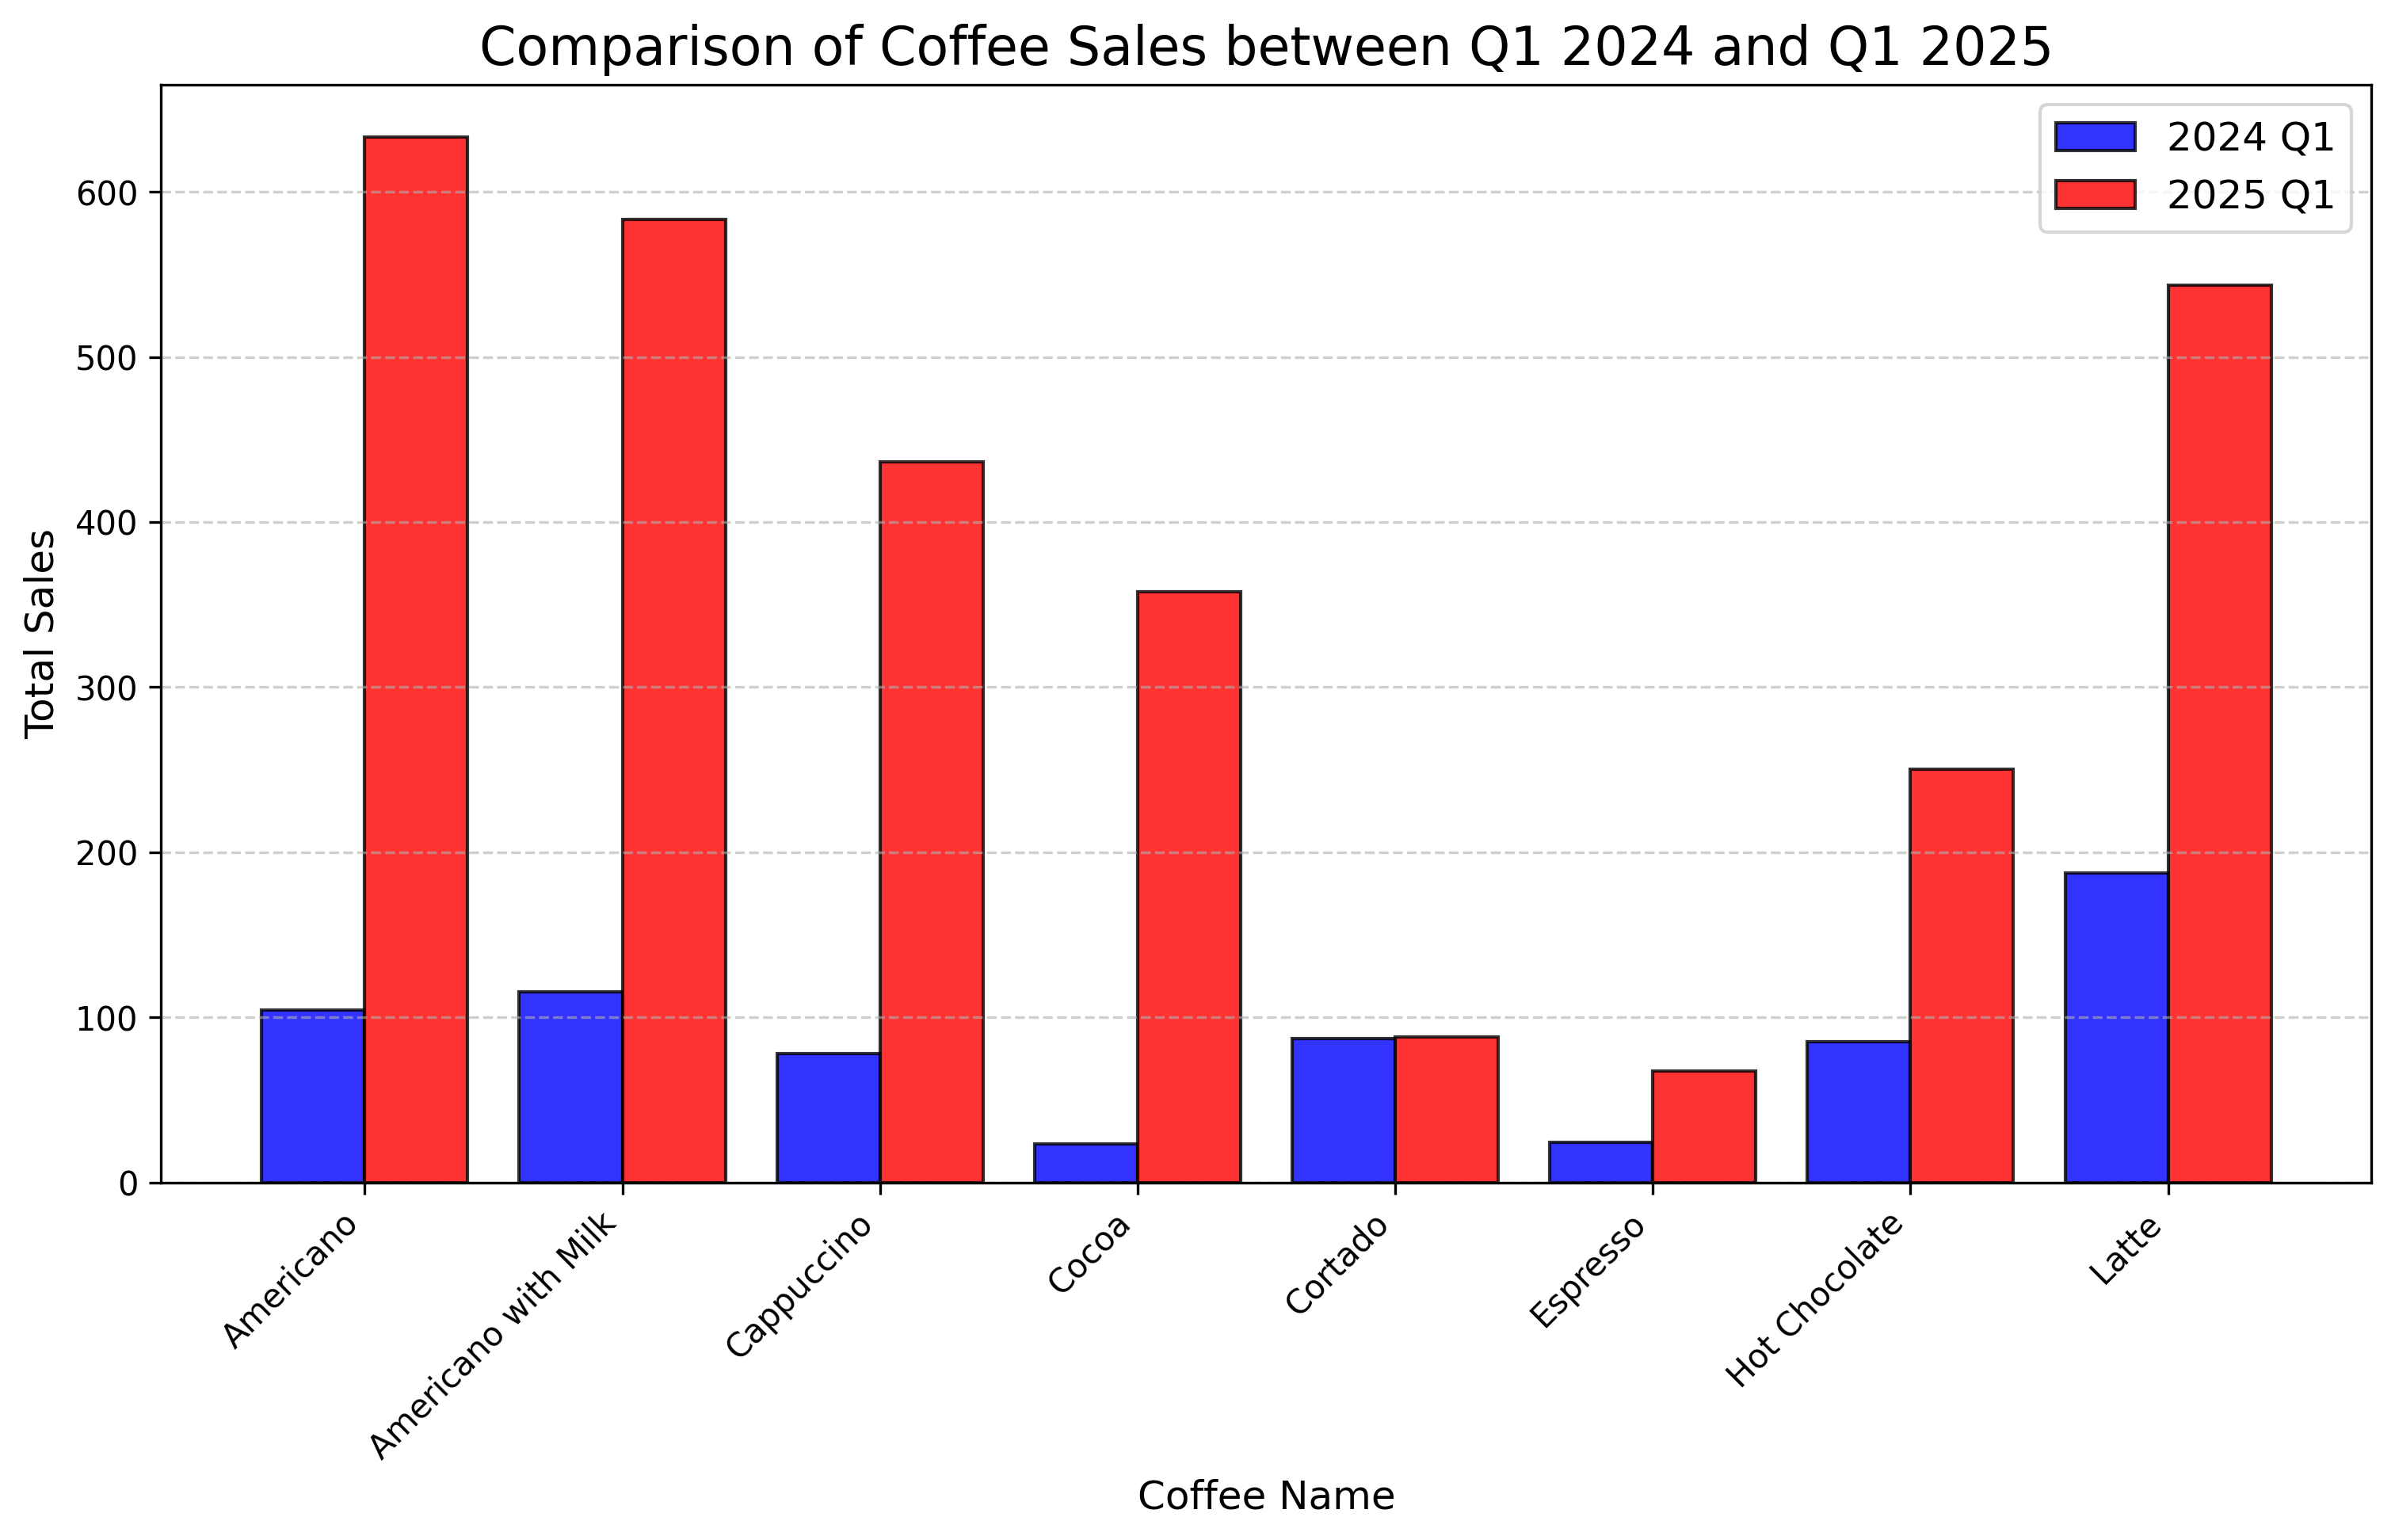

In [18]:
# 获取 <execute_python> 标签中的代码
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v2)
if match:
    reflected_code = match.group(1).strip()
    exec_globals = {"df": df}
    exec(reflected_code, exec_globals)

# 若代码运行成功，应已生成文件 chart_v2.png
utils.print_html(
    content="chart_v2.png",
    title="重新生成的图表（V2）",
    is_image=True
)

### 4. 整体串联 — 构建端到端工作流

现在我们把所有步骤封装成一个可自动运行的工作流，智能体可以从头到尾执行。

`run_workflow` 函数将之前实现的各组件串联起来：

1) **加载并准备数据** —— 通过 `utils.load_and_prepare_data(...)`。  
2) **生成 V1 代码** —— 使用 `generate_chart_code(...)` 返回首版 matplotlib 代码（包裹在 `<execute_python>` 标签中）。  
3) **立即执行 V1** —— 工作流提取 `<execute_python>` 标签之间的代码并运行，生成第一张图。  
4) **反思并改进** —— `reflect_on_image_and_regenerate(...)` 根据指令对 V1 图像（以及原始代码）进行评审，返回精炼的**反馈**与**改进代码（V2）**。  
5) **立即执行 V2** —— 提取并执行改进版代码，生成更优的图表。

### 该工作流的入参
- **`dataset_path`**：输入 CSV 的路径。  
- **`user_instructions`**：图表需求（例如：“使用 coffee_sales.csv 中的数据，创建一张对比 2024 与 2025 年第一季度咖啡销售的图表。”）。  
- **`generation_model`**：用于初始代码生成的模型。  
- **`reflection_model`**：用于图像反思与代码改进的模型。  
- **`image_basename`**：保存图像的基本文件名（例如 `chart_v1.png`、`chart_v2.png`）。  

> 说明：图表执行步骤被有意**硬编码**为在代码生成/改进后立刻运行。这与课程中的工作流一致，帮助你在继续之前看到每个草稿的输出。


In [19]:
def run_workflow(
    dataset_path: str,
    user_instructions: str,
    generation_model: str,
    reflection_model: str,   
    image_basename: str = "chart",
):
    """
    端到端流水线：
      1) 加载数据集
      2) 生成 V1 代码
      3) 执行 V1 → 生成 chart_v1.png
      4) 反思 V1（图像 + 原始代码）→ 反馈 + 改进代码
      5) 执行 V2 → 生成 chart_v2.png

    返回包含所有产物（代码、反馈、图像路径）的字典。
    """
    # 0) 加载数据集；utils 负责解析并生成特征（如年/季度）
    df = utils.load_and_prepare_data(dataset_path)
    utils.print_html(df.sample(n=5), title="数据集的随机样本")

    # 图表保存路径
    out_v1 = f"{image_basename}_v1.png"
    out_v2 = f"{image_basename}_v2.png"

    # 1) Generate code (V1)
    utils.print_html("步骤 1：生成绘图代码（V1）… 📈")
    code_v1 = generate_chart_code(
        instruction=user_instructions,
        model=generation_model,
        out_path_v1=out_v1,
    )
    utils.print_html(code_v1, title="LLM 输出的首版代码（V1）")

    # 2) 执行 V1（固定流程：提取 <execute_python> 代码块并立即运行）
    utils.print_html("步骤 2：执行绘图代码（V1）… 💻")
    match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1)
    if match:
        initial_code = match.group(1).strip()
        exec_globals = {"df": df}
        exec(initial_code, exec_globals)
    utils.print_html(out_v1, is_image=True, title="生成的图表（V1）")

    # 3) 对 V1（图像 + 原始代码）进行反思以获取反馈并生成改进代码（V2）
    utils.print_html("步骤 3：对 V1（图像 + 代码）进行反思并生成改进… 🔁")
    feedback, code_v2 = reflect_on_image_and_regenerate(
        chart_path=out_v1,
        instruction=user_instructions,
        model_name=reflection_model,
        out_path_v2=out_v2,
        code_v1=code_v1,  # 传入原始代码作为上下文
    )
    utils.print_html(feedback, title="对 V1 的反思反馈")
    utils.print_html(code_v2, title="LLM 输出的改进版代码（V2）")

    # 4) 执行 V2（固定流程：提取 <execute_python> 代码块并立即运行）
    utils.print_html("步骤 4：执行改进后的绘图代码（V2）… 🖼️")
    match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v2)
    if match:
        reflected_code = match.group(1).strip()
        exec_globals = {"df": df}
        exec(reflected_code, exec_globals)
    utils.print_html(out_v2, is_image=True, title="重新生成的图表（V2）")

    return {
        "code_v1": code_v1,
        "chart_v1": out_v1,
        "feedback": feedback,
        "code_v2": code_v2,
        "chart_v2": out_v2,
    }


### 4.2. 试运行工作流

现在轮到你用课程中的更新示例来运行完整的工作流。

- **建议使用的指令：**  
  “使用 coffee_sales.csv 中的数据，创建一张对比 2024 与 2025 年第一季度咖啡销售的图表。”

当你用这条指令运行工作流时，它会：
1. 生成用于创建图表的首版代码。  
2. 立即执行该代码，生成图表的第一个版本（V1）。  
3. 对图表与原始代码进行反思，产出反馈与改进版代码（V2）。  
4. 执行改进后的代码，生成更优的图表（V2）。  

### 自定义与实验

在完成上述示例后，你可以将 `user_instructions` 参数替换为自己的图表需求。  
记得同时调整 `image_basename`，让每次运行保存到不同的文件名 —— 这可以避免覆盖并保持结果有序。

### 模型选择

你可以混合搭配不同模型用于生成与反思。例如：
- 生成使用更快的模型（如 `gpt-4.1-mini` 或 `gpt-3.5-turbo`）。  
- 反思使用更强的推理模型（如 `gpt-4.1` 或 `claude-3-7-sonnet`）。  

这种灵活性有助于你探索速度与质量之间的取舍。

👉 **行动建议：** 先用课程示例指令运行一次工作流，然后尝试你自己的提示词，看看智能体如何适配！

date,time,cash_type,card,price,coffee_name,quarter,month,year
2024-06-09,15:39,card,ANON-0000-0000-0279,3.282,Americano with Milk,2,6,2024
2024-05-12,11:22,card,ANON-0000-0000-0160,3.772,Latte,2,5,2024
2024-11-15,07:47,card,ANON-0000-0000-0769,3.086,Americano with Milk,4,11,2024
2025-02-05,09:47,card,ANON-0000-0000-1171,2.106,Espresso,1,2,2025
2024-03-10,16:48,cash,NaN,3.500,Americano with Milk,1,3,2024



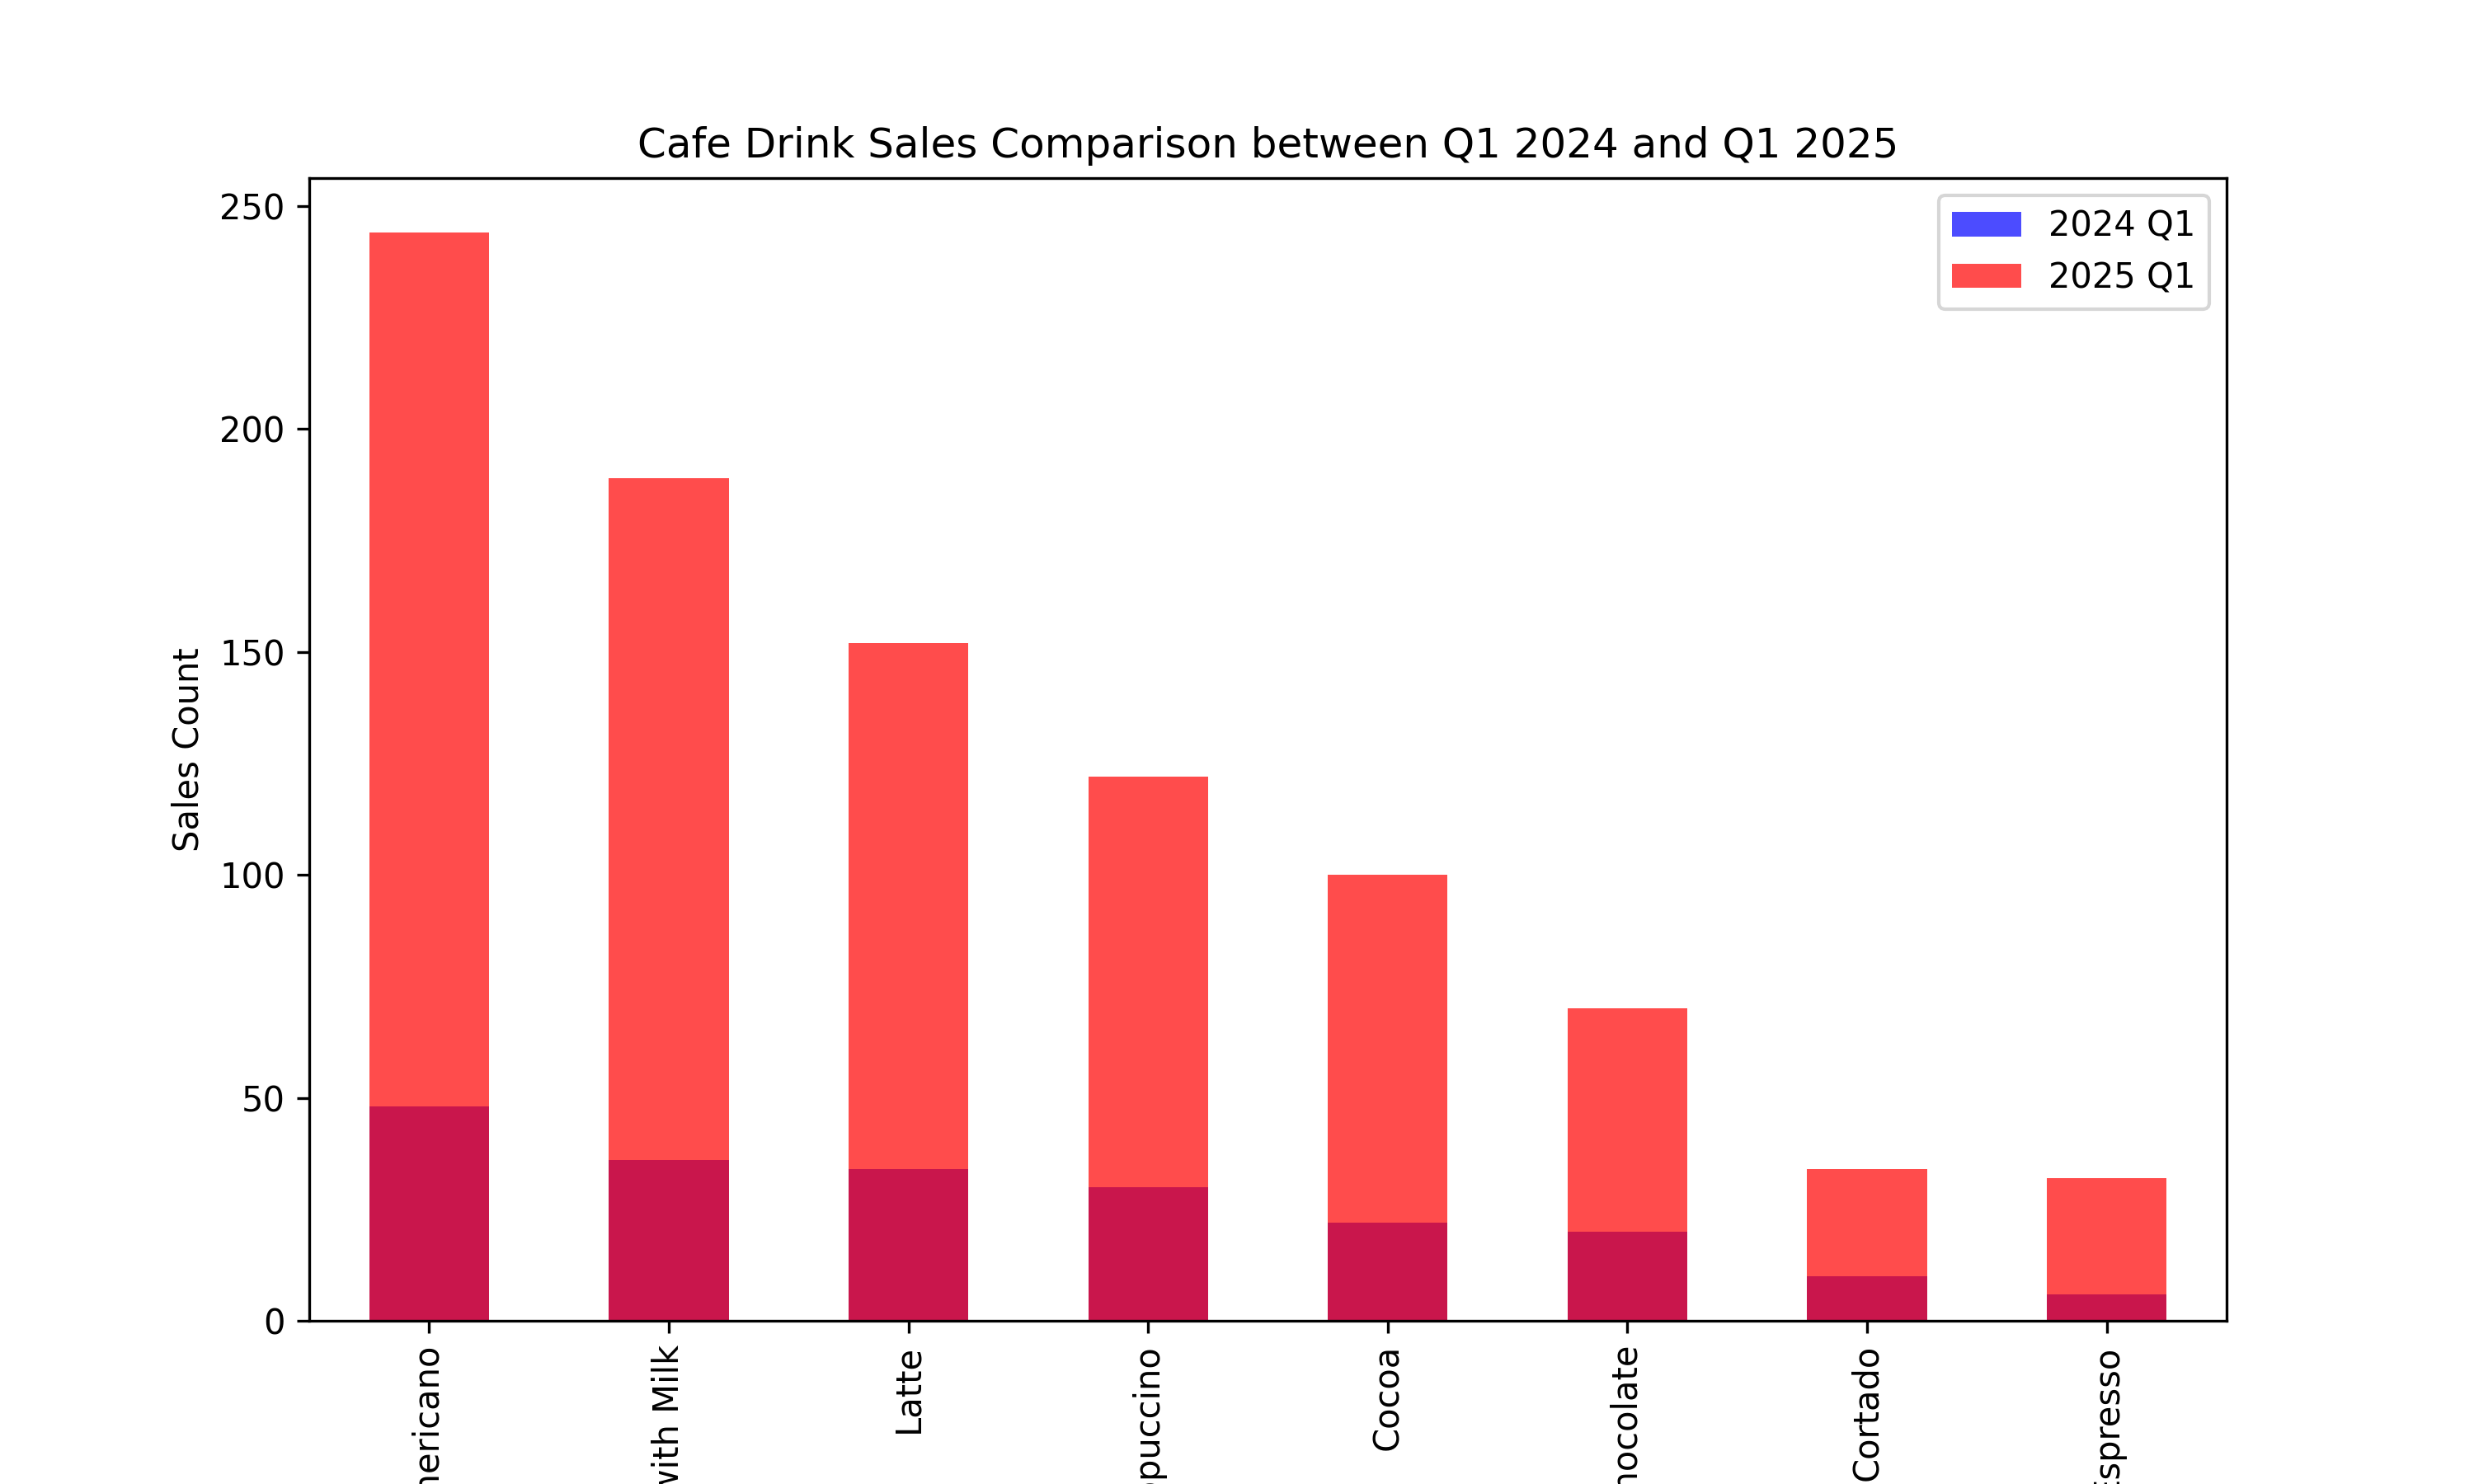


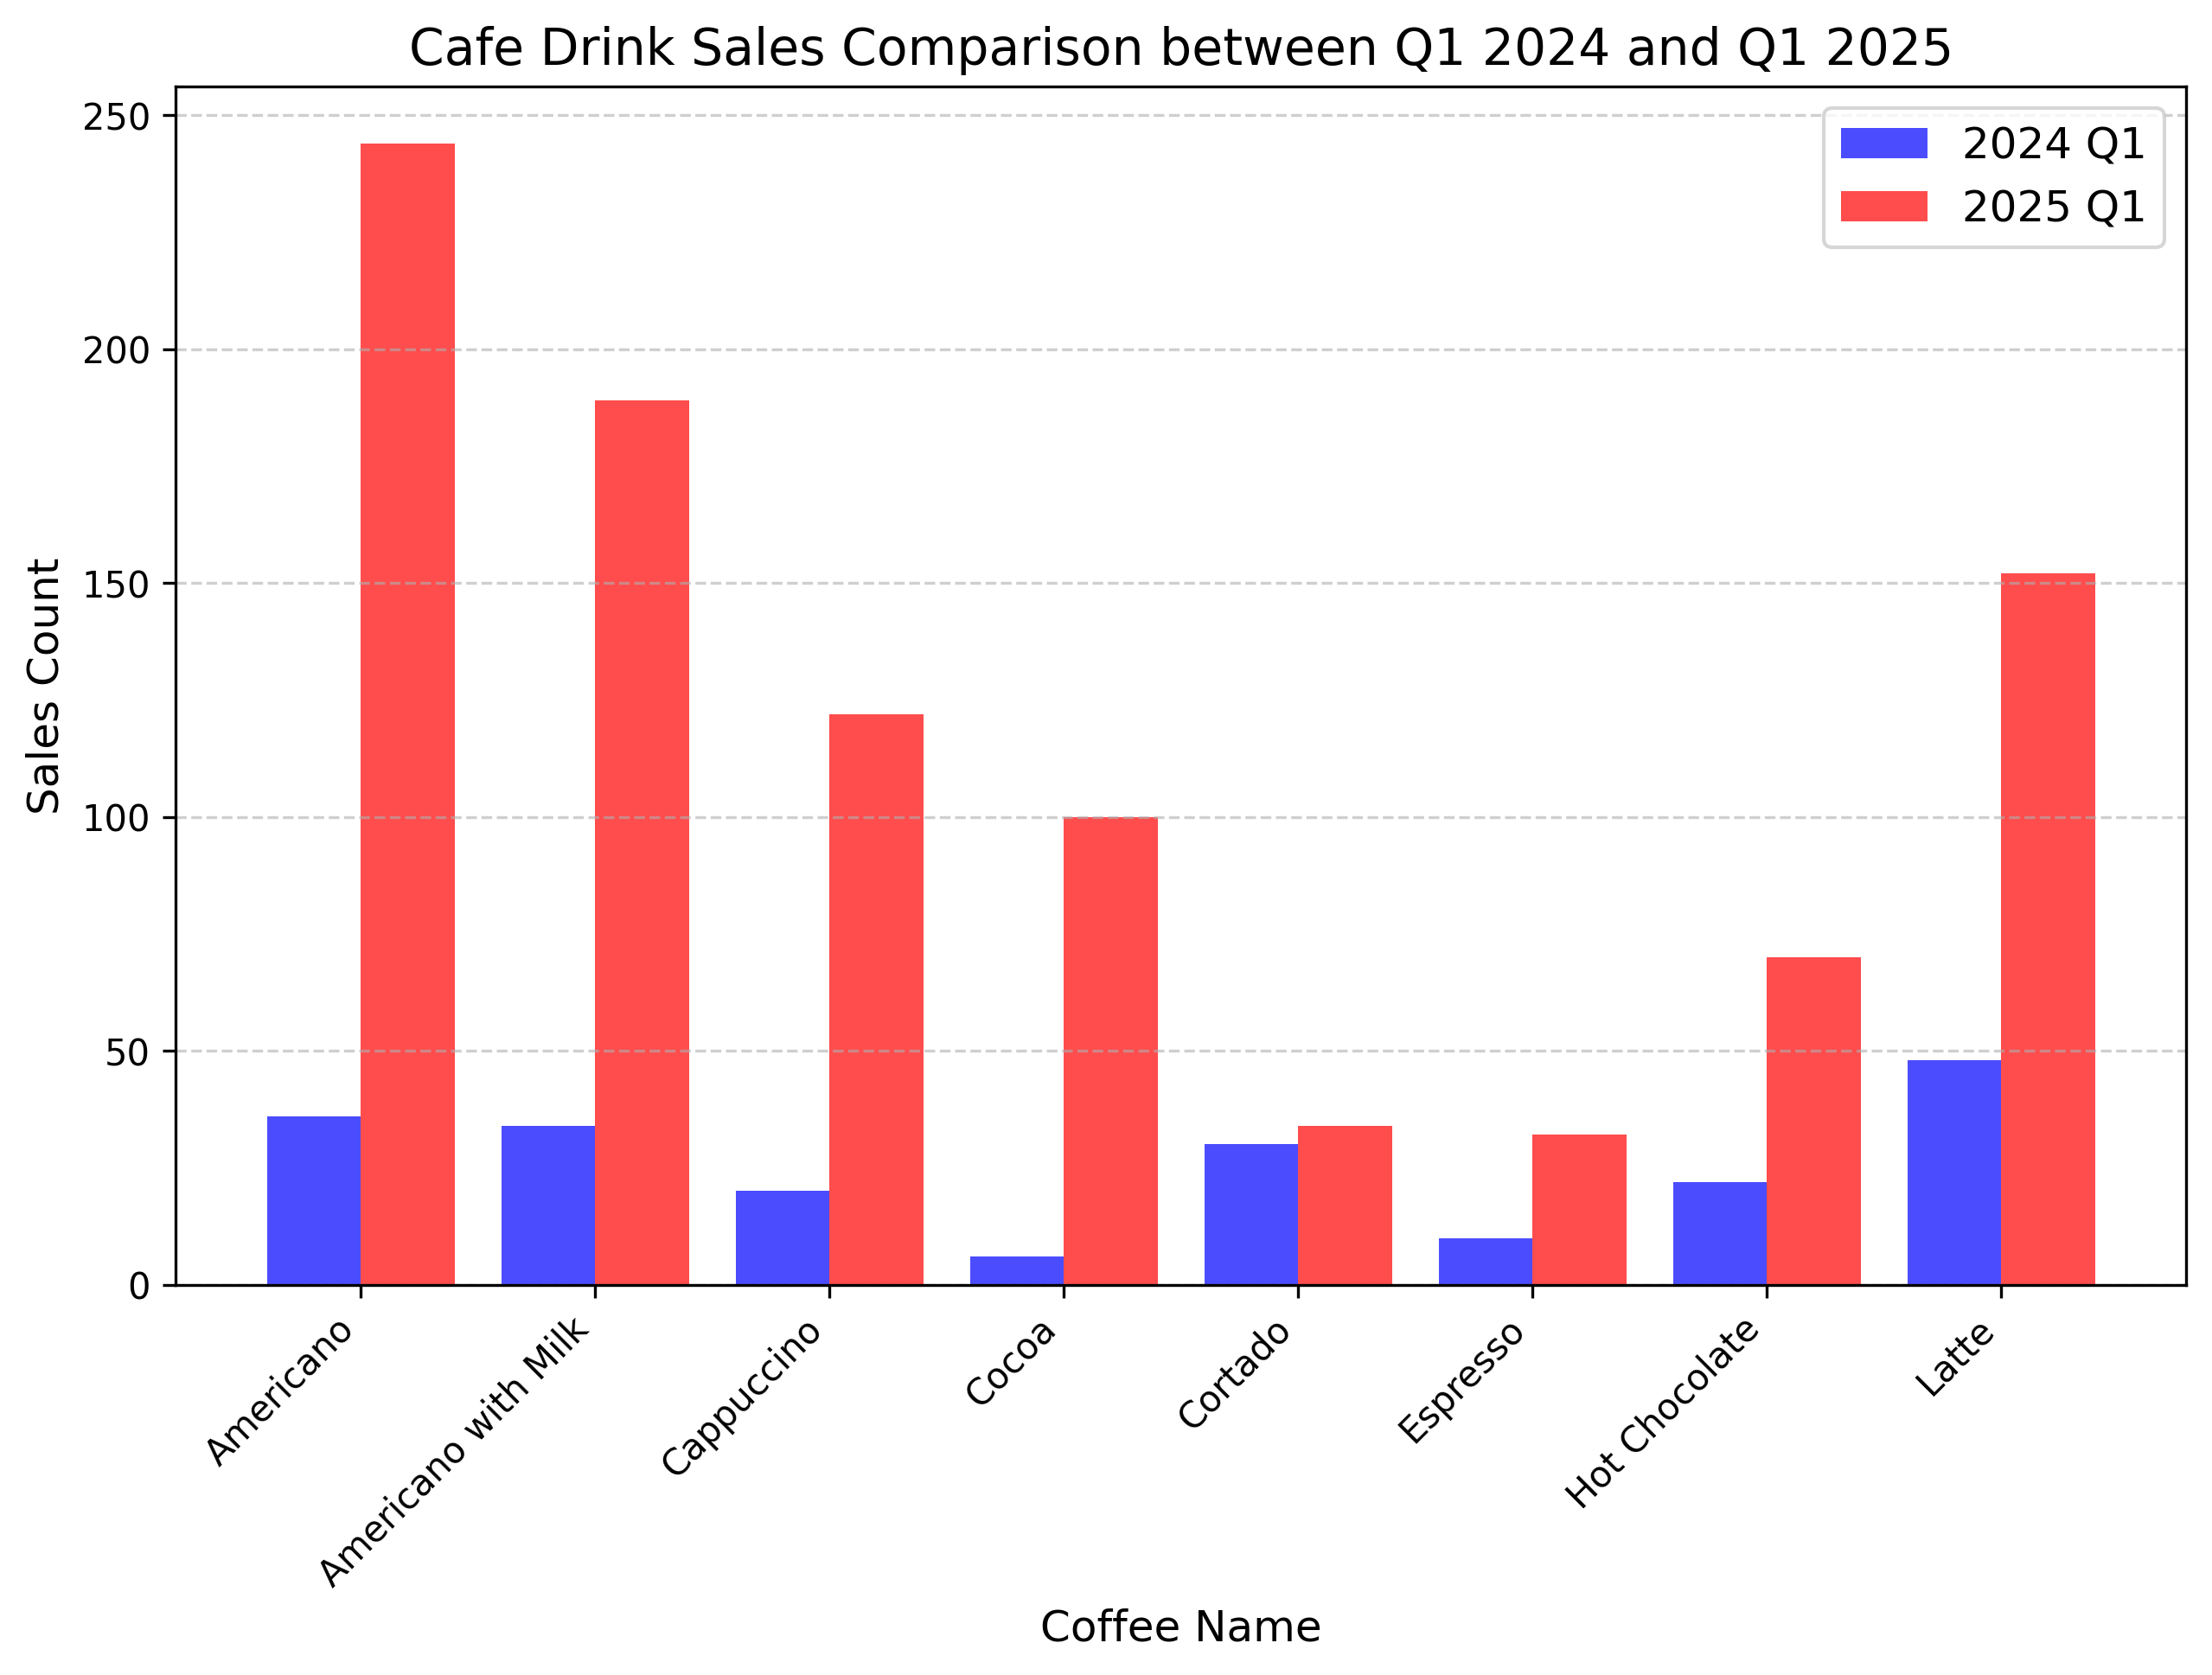

In [35]:
# 在此填写你的更新
user_instructions="使用 coffee_sales.csv 中的数据，创建一张对比 2024 与 2025 年第一季度咖啡销售的图表。" # 在此填写你的指令
#generation_model="gpt-4.1-mini"
#reflection_model="o4-mini"
generation_model = "Qwen/Qwen2.5-Coder-7B-Instruct"
reflection_model = "Qwen/Qwen2.5-VL-32B-Instruct"

image_basename="drink_sales"

# 运行完整的 Agentic 工作流
_ = run_workflow(
    dataset_path="coffee_sales.csv",
    user_instructions=user_instructions,
    generation_model=generation_model,
    reflection_model=reflection_model,
    image_basename=image_basename
)

## 5. 关键收获

在本次实验中，你练习了使用反思来改进图表输出。
你学会了：

* 生成初始图表（V1）。
* 评审并将其改进为更好的版本（V2）。
* 使用不同模型自动化完整工作流。

核心思想：反思可以帮助你得到更清晰、更准确、更有效的可视化。


<div style="border:1px solid #22c55e; border-left:6px solid #16a34a; background:#dcfce7; border-radius:6px; padding:14px 16px; color:#064e3b; font-family:system-ui,-apple-system,Segoe UI,Roboto,Ubuntu,Cantarell,Noto Sans,sans-serif;">

🎉 <strong>恭喜！</strong>  

你已完成构建**智能体图表生成工作流**的实验。  
在此过程中，你练习了生成图表、对其质量进行反思，并将其打磨为更清晰、更有效的可视化。  

凭借这些技能，你已经能够设计自动创建数据可视化的智能体流水线，同时确保结果准确、可解释且精致。 🌟  

</div>

